In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import math
import numpy as np
import matplotlib.pyplot as plt

from ecc import *

# Módulo 1: Fundamentos Algebraicos

### El problema del alias

Necesitamos que la gente pueda enviarnos dinero. Pero no pueden enviarlo a
nuestra clave privada — si la compartimos, cualquiera que la vea puede gastar
nuestros fondos. Así que necesitamos un **alias**: una identidad pública
derivada de nuestra clave privada a la que la gente pueda enviar, pero que no
revele nada sobre la clave en sí.

```
  CLAVE PRIVADA (secreta)         CLAVE PÚBLICA (alias)
 ┌──────────────┐  d × G   ┌──────────────┐
 │   d  (256b)  │ ───────→ │   P  (punto)  │   ← cualquiera puede enviar aquí
 └──────────────┘   fácil   └──────────────┘
                  ←───────
                  imposible                       ← nadie puede revertirlo
```

Ese alias es la **clave pública**: $P = d \times G$, donde $d$ es nuestro
secreto y $G$ es un punto de partida conocido. Cualquiera puede enviar bitcoin
a $P$. Nadie puede calcular $d$ a partir de $P$.

### El problema de la prueba

Cuando queremos gastar, necesitamos **demostrar que $P$ realmente es nuestro
alias** — que conocemos el $d$ detrás de él — sin revelar $d$.

```
  FIRMA                               VERIFICACIÓN
 ┌──────────────────────┐     ┌──────────────────────────┐
 │  entradas:           │     │  entradas:                │
 │    d  (clave privada)│     │    P  (clave pública)     │
 │    tx (transacción)  │     │    tx (transacción)       │
 │                      │     │    (r, s) (firma)         │
 │  salida:             │     │                           │
 │    (r, s) firma      │     │  salida:                  │
 │                      │     │    ✓ válida o  ✗ inválida │
 └──────────────────────┘     └──────────────────────────┘
     solo el firmante              cualquier persona
     puede producir esto           puede verificar esto
```

Las curvas elípticas nos dan exactamente esto. La operación $d \times G$
("multiplicar un punto en una curva por un escalar") es fácil de computar
hacia adelante e imposible de revertir. Esa es la función unidireccional.

### Cómo llegamos aquí: de ElGamal a ECC

ECC no surgió de la nada. La idea de conectar una función unidireccional a un
protocolo de firma/verificación ya estaba resuelta antes de que las curvas
elípticas entraran en escena:

```
  1985: ElGamal                          1985: Koblitz & Miller
 ┌─────────────────────────┐            ┌─────────────────────────┐
 │  Grupo: enteros mod p   │            │  Grupo: CE sobre F_p    │
 │  Problema difícil: PLD  │            │  Problema difícil: PLDE │
 │  Tamaño clave: 3072 bits│            │  Tamaño clave: 256 bits │
 │                         │  "Mismo    │                         │
 │  Propiedades abelianas: │  esquema,  │  Propiedades abelianas: │
 │  ✓ gratis (de libro     │  grupo     │  ✓ verificadas (hubo    │
 │    desde los 1800s)     │  más       │    que comprobarlas)    │
 └─────────────────────────┘  fuerte"→  └─────────────────────────┘
```

ElGamal construyó su esquema de firma sobre el problema del logaritmo discreto
en enteros módulo un primo. Las matemáticas ya estaban ahí — los enteros módulo
un primo bajo multiplicación forman naturalmente un grupo abeliano (cerradura,
asociatividad, inversos, conmutatividad — todo gratis, todo de libro desde los
1800s). No tuvo que buscar esas propiedades; venían con el territorio. Su
innovación fue el *esquema en sí mismo*.

El problema: el logaritmo discreto sobre enteros mod $p$ puede atacarse con
algoritmos subexponenciales (cálculo de índices), así que se necesitan claves
enormes — 3072 bits — para estar seguros.

Koblitz y Miller dijeron: "Buen esquema. Mismas ecuaciones. Pero tu grupo es
débil — cambiémoslo por uno más fuerte." Descubrieron que las curvas elípticas
sobre cuerpos finitos también forman un grupo abeliano, pero uno donde no se
conoce ningún ataque subexponencial. Misma seguridad, claves de 256 bits en
lugar de 3072.

**Ahí es cuando las propiedades de grupo se convirtieron en una lista de
verificación explícita** — porque ahora estás trasplantando un esquema a un
nuevo entorno matemático y tienes que verificar que el nuevo entorno todavía
lo soporta.

**Pero tener una función unidireccional no es suficiente.** Si las matemáticas
no se comportan bien, las ecuaciones de firma se desmoronan. Por ejemplo:

- ¿Qué pasa si $d \times G$ produce un resultado que ni siquiera es un punto
  válido? Entonces nuestro alias $P$ no tiene sentido. Consideremos los números
  impares: $\{1, 3, 5, 7, ...\}$. La multiplicación funciona bien — $3 \times 5
  = 15$, sigue siendo impar. Pero la suma se sale: $5 + 5 = 10$, que no está en
  el conjunto. Si tu operación puede escapar del conjunto, todo el sistema se
  desmorona. Y no es solo una cuestión de higiene matemática — **la seguridad
  depende de permanecer dentro de un conjunto finito donde las salidas parezcan
  aleatorias.** Sobre los números reales, si $P$ está "lejos" de $G$, eso filtra
  que $d$ es grande. En un grupo finito, todo da la vuelta — no hay sentido de
  "lejos" — así que la salida no revela nada sobre la entrada.
- ¿Qué pasa si no puedes calcular inversos? Entonces la ecuación de verificación
  no puede reordenarse para comprobar la firma.
- ¿Qué pasa si el orden de las operaciones importa? Entonces el firmante y el
  verificador obtendrían resultados diferentes con las mismas entradas.

Para evitar todo esto, necesitamos restringir el entorno matemático. Necesitamos
un sistema donde:

| Propiedad | Qué garantiza | Por qué la necesitamos |
|-----------|--------------|----------------------|
| **Cerradura** | Combinar dos elementos siempre da otro elemento válido | $d \times G$ garantiza producir un punto válido |
| **Asociatividad** | El agrupamiento no importa | La ecuación de firma puede reordenarse y simplificarse |
| **Identidad** | Hay un elemento neutro que "no hace nada" | Necesitamos un concepto de cero — el punto en el infinito |
| **Inverso** | Toda operación puede deshacerse | La verificación necesita calcular $s^{-1}$ |
| **Conmutatividad** | El orden no importa | Firmante y verificador llegan al mismo resultado independientemente |

Un sistema con las primeras cuatro propiedades se llama **grupo**. Añade la
conmutatividad y se convierte en un **grupo abeliano**. Esta es exactamente la
estructura que forman los puntos de una curva elíptica — y es la razón por la
que usamos curvas elípticas para las firmas de Bitcoin en lugar de cualquier
otra función unidireccional.

Durante un rato, nos enfocaremos en qué son estas propiedades, cómo funcionan
y cómo se combinan para crear el entorno matemático que necesitamos.

---

## 1.1 Grupos

Un **grupo** es un conjunto $S$ con una operación binaria $\cdot$ que satisface
cuatro axiomas. Añade un quinto (conmutatividad) y se convierte en un **grupo
abeliano**:

| Axioma | Enunciado | Intuición |
|--------|-----------|----------|
| **Cerradura** | $\forall a,b \in S: a \cdot b \in S$ | Combinar elementos permanece en el conjunto |
| **Asociatividad** | $(a \cdot b) \cdot c = a \cdot (b \cdot c)$ | El agrupamiento no importa |
| **Identidad** | $\exists e: a \cdot e = e \cdot a = a$ | Hay un elemento que "no hace nada" |
| **Inverso** | $\forall a, \exists a^{-1}: a \cdot a^{-1} = e$ | Toda acción puede deshacerse |
| **Conmutatividad** | $a \cdot b = b \cdot a$ | El orden no importa |

Trabajemos con cada uno usando números pequeños para que los conceptos queden
sólidos antes de conectarlos con las curvas elípticas.

### Cerradura

$\forall a,b \in S: a \cdot b \in S$ — combinar dos elementos siempre da
otro elemento en el mismo conjunto.

Usaremos los **enteros módulo 7** como nuestro conjunto: $\{0, 1, 2, 3, 4, 5, 6\}$,
con la suma como operación.

¿Por qué módulo un primo? Porque sobre los números reales, los resultados crecen
sin límite — y peor aún, una computadora no puede representar los reales con
exactitud. Los errores de punto flotante se acumulan, y tras suficientes
operaciones, tu resultado se desvía de la curva. Trabajar módulo un primo
mantiene todo en un **conjunto finito** donde cada resultado es exacto. También
destruye cualquier noción de "cercanía" entre entradas y salidas, que es lo que
hace que el problema del logaritmo discreto sea difícil para los atacantes.

In [2]:
n = 7
S = list(range(n))
set_str = "{" + ", ".join(map(str, S)) + "}"

print(f"Conjunto: Z_7 = {set_str}")
print(f"\n(3 + 5) mod 7 = {(3 + 5) % n}  ← sigue en el conjunto  ✓")
print(f"(6 + 6) mod 7 = {(6 + 6) % n}  ← da la vuelta, sigue en el conjunto  ✓")

print(f"\nComparación con los números impares bajo suma:")
print(f"5 + 5 = 10  ← 10 es par, escapó del conjunto  ✗  (cerradura violada)")
print(f"3 + 7 = 10  ← mismo problema")
print(f"\nPor eso trabajamos módulo un primo: el resultado siempre queda en el conjunto.")

Conjunto: Z_7 = {0, 1, 2, 3, 4, 5, 6}

(3 + 5) mod 7 = 1  ← sigue en el conjunto  ✓
(6 + 6) mod 7 = 5  ← da la vuelta, sigue en el conjunto  ✓

Comparación con los números impares bajo suma:
5 + 5 = 10  ← 10 es par, escapó del conjunto  ✗  (cerradura violada)
3 + 7 = 10  ← mismo problema

Por eso trabajamos módulo un primo: el resultado siempre queda en el conjunto.


### Asociatividad

$(a \cdot b) \cdot c = a \cdot (b \cdot c)$ — el agrupamiento no importa.

Suena aburrido, pero es esencial. La ecuación de firma ECDSA necesita
reordenarse durante la verificación — los términos se mueven, reagrupan y
simplifican. Si el orden en que evalúas las subexpresiones cambia el resultado,
todo se rompe. La asociatividad garantiza que puedes reordenar libremente.

In [3]:
a, b, c = 2, 4, 6

left  = ((a + b) % n + c) % n   # (2+4) primero, luego +6
right = (a + (b + c) % n) % n   # (4+6) primero, luego +2

print(f"({a} + {b}) + {c}  mod 7 = {left}")
print(f" {a} + ({b} + {c}) mod 7 = {right}")
print(f"Mismo resultado: {left == right}  ✓")

(2 + 4) + 6  mod 7 = 5
 2 + (4 + 6) mod 7 = 5
Mismo resultado: True  ✓


### Identidad

$\exists e: a \cdot e = e \cdot a = a$ — hay un elemento que "no hace nada".

Para la suma módulo 7, la identidad es **0** — sumar cero no cambia nada.

En una curva elíptica, la identidad es el **punto en el infinito** $\mathcal{O}$.
Cumple el rol del cero: sumarlo a cualquier punto devuelve el mismo punto.
Necesitamos esto para definir qué significa que un punto tenga un inverso (la
siguiente propiedad), porque "inverso" significa "aquello que te devuelve a la
identidad.".

In [4]:
e = 0  # elemento identidad para suma mod 7

for a in range(n):
    assert (a + e) % n == a
    assert (e + a) % n == a

print(f"Elemento identidad: {e}")
print(f"5 + 0 = {(5 + 0) % n}  ✓")
print(f"0 + 3 = {(0 + 3) % n}  ✓")
print(f"Verificado: a + 0 = 0 + a = a para todo elemento en Z_7  ✓")

Elemento identidad: 0
5 + 0 = 5  ✓
0 + 3 = 3  ✓
Verificado: a + 0 = 0 + a = a para todo elemento en Z_7  ✓


### Inverso

$\forall a, \exists a^{-1}: a \cdot a^{-1} = e$ — todo elemento tiene un
compañero que lo "deshace", llevándote de vuelta a la identidad.

Para la suma módulo 7: el inverso de 3 es 4, porque $(3 + 4) \bmod 7 = 0$
(la identidad).

Esto es crítico para la verificación. Cuando el verificador comprueba una firma,
necesita calcular cosas como $s^{-1}$ — el inverso multiplicativo de $s$. Si
los inversos no existieran, la ecuación de verificación no podría resolverse.

In [5]:
print("Todo elemento en Z_7 tiene un inverso aditivo:\n")
for a in range(n):
    inv = (n - a) % n
    print(f"  {a} + {inv} = {(a + inv) % n}  (mod 7)  → el inverso de {a} es {inv}")

Todo elemento en Z_7 tiene un inverso aditivo:

  0 + 0 = 0  (mod 7)  → el inverso de 0 es 0
  1 + 6 = 0  (mod 7)  → el inverso de 1 es 6
  2 + 5 = 0  (mod 7)  → el inverso de 2 es 5
  3 + 4 = 0  (mod 7)  → el inverso de 3 es 4
  4 + 3 = 0  (mod 7)  → el inverso de 4 es 3
  5 + 2 = 0  (mod 7)  → el inverso de 5 es 2
  6 + 1 = 0  (mod 7)  → el inverso de 6 es 1


### Conmutatividad (la propiedad Abeliana)

$a \cdot b = b \cdot a$ — el orden no importa.

Esto es lo que hace a un grupo **abeliano**. El firmante calcula la firma usando
una secuencia de operaciones; el verificador la comprueba usando una secuencia
diferente. Ambos deben llegar al mismo resultado. Si el orden importara,
obtendrían resultados diferentes con las mismas entradas — y la verificación
fallaría incluso para firmas válidas.

In [6]:
print("Verificación de conmutatividad para todos los pares en Z_7:\n")
all_commute = True
for a in range(n):
    for b in range(n):
        if (a + b) % n != (b + a) % n:
            all_commute = False

print(f"  2 + 5 = {(2+5)%n},  5 + 2 = {(5+2)%n}  ✓")
print(f"  4 + 6 = {(4+6)%n},  6 + 4 = {(6+4)%n}  ✓")
print(f"\n  Los {n*n} pares conmutan: {all_commute}  → Z_7 es abeliano  ✓")

Verificación de conmutatividad para todos los pares en Z_7:

  2 + 5 = 0,  5 + 2 = 0  ✓
  4 + 6 = 3,  6 + 4 = 3  ✓

  Los 49 pares conmutan: True  → Z_7 es abeliano  ✓


### Las cinco en acción: la ecuación ECDSA

Ahora podemos ver por qué cada propiedad importa. La ecuación de firma en ECDSA es:

$$s = k^{-1}(z + r \cdot d) \bmod N$$

El verificador no conoce $d$ ni $k$. Reordena la ecuación así:

$$R' = \frac{z}{s} \times G + \frac{r}{s} \times P$$

y comprueba si $R'$ coincide. Esa reordenación utiliza:

| Paso | Propiedad utilizada |
|------|---------------------|
| $k^{-1}$ y $s^{-1}$ existen | **Inverso** |
| $\frac{z}{s} \times G$ produce un punto válido en la curva | **Cerradura** |
| Los términos pueden reagruparse y factorizarse | **Asociatividad** |
| Sumar el punto en el infinito cuando es necesario | **Identidad** |
| Firmante y verificador obtienen el mismo resultado desde distintos órdenes | **Conmutatividad** |

Sin cualquiera de estas, la ecuación no puede formarse, no puede reordenarse,
o produce resultados diferentes en cada lado.

## El grupo necesita un hogar

Los grupos nos dan una operación — la suma de puntos — y es lo que usa el
esquema de firma. La firma y verificación se construyen enteramente sobre la
suma y escalamiento de puntos.

Pero la curva tiene que **existir** primero. La ecuación $y^2 = x^3 + ax + b$
define qué pares $(x, y)$ están en la curva. Para evaluarla, necesitas calcular
cuadrados, cubos, sumas y multiplicaciones de coordenadas. Y la fórmula de la
pendiente para sumar dos puntos requiere división:
$\lambda = (y_2 - y_1) / (x_2 - x_1)$.

Nada de eso es la operación de grupo. Es el **sistema numérico en el que viven
las coordenadas** — el terreno sobre el que se dibuja la curva. El cuerpo es
infraestructura. El grupo es lo que realmente usamos. El cuerpo existe para
que el grupo pueda existir.

Entonces, ¿qué tipo de sistema numérico necesitamos para las coordenadas?

---

## 1.2 Anillos — dos operaciones

La ecuación de la curva $y^2 = x^3 + ax + b$ usa tanto **suma como
multiplicación**. Un grupo solo nos da una operación. Para siquiera *escribir*
la curva, necesitamos un conjunto donde ambas estén definidas.

Un **anillo** es exactamente eso — un conjunto con dos operaciones donde:
- La suma forma un grupo abeliano
- La multiplicación es asociativa y distribuye sobre la suma

**Ejemplo: $\mathbb{F}_7$ como anillo.**
Toma el conjunto $\{0, 1, 2, 3, 4, 5, 6\}$ con aritmética módulo 7.
Puedes sumar: $5 + 4 = 9 \equiv 2 \pmod{7}$ — sigue en el conjunto.
Puedes multiplicar: $3 \times 5 = 15 \equiv 1 \pmod{7}$ — sigue en el conjunto.
La distributividad funciona: $3 \times (4 + 5) \equiv 3 \times 2 \equiv 6$ y
$3 \times 4 + 3 \times 5 \equiv 5 + 1 \equiv 6 \pmod{7}$ — misma respuesta.

Así que $\mathbb{F}_7$ es un anillo. Puedes evaluar $y^2 = x^3 + 7$ con él —
sustituye $x = 2$: el lado derecho es $2^3 + 7 = 15 \equiv 1 \pmod{7}$,
el lado izquierdo necesita $y^2 \equiv 1$, y $y = 1$ funciona ($1^2 = 1$).

¿Pero siempre podemos dividir? La fórmula de la pendiente necesita
$\Delta y / \Delta x$. Un anillo solo no lo garantiza — necesitamos un cuerpo
para eso.

## 1.3 Cuerpos — porque necesitamos dividir

Tenemos un anillo. Podemos escribir $y^2 = x^3 + 7$. Pero ahora veamos qué
pasa cuando realmente intentamos **sumar dos puntos** en la curva. La pendiente
entre dos puntos es:

$$\lambda = \frac{y_2 - y_1}{x_2 - x_1}$$

Eso es **división**. Y un anillo no garantiza que puedas dividir — en los
enteros, $7 / 3$ no es un entero. Estamos atascados.

Un **cuerpo** resuelve esto. Un cuerpo es un anillo donde todo elemento no nulo
tiene un inverso multiplicativo — lo que significa que la división siempre
funciona. Los reales son un cuerpo. Los racionales son un cuerpo. Los enteros
NO lo son (porque $3$ no tiene inverso).

Así que el requisito es: cualquier sistema numérico en el que vivan las
coordenadas de la curva debe ser un cuerpo, o no podemos calcular pendientes,
y sin pendientes no podemos sumar puntos.

### ¿Pero cuál cuerpo?

Los racionales funcionan matemáticamente — $7/3$ está bien. Pero son terribles
para la criptografía:
- **Conjunto infinito** — sin envolvimiento, sin grupo finito, sin problema del logaritmo discreto
- **Predecible** — entradas cercanas dan salidas cercanas (el atacante puede "acercarse")
- **Inexacto en computadoras** — el punto flotante redondea, y el redondeo lo rompe todo

Necesitamos un cuerpo que sea **finito**, **exacto** y de **apariencia aleatoria**.

### La respuesta: $\mathbb{F}_p$ — enteros módulo un primo

Dado un primo $p$, el conjunto $\{0, 1, 2, \ldots, p-1\}$ con aritmética modular
forma un **cuerpo finito** (también llamado cuerpo de Galois).

¿Por qué funciona la división? Porque $p$ es primo, todo elemento no nulo tiene
un inverso multiplicativo. Lo calculamos con el **pequeño teorema de Fermat**:
$a^{-1} = a^{p-2} \bmod p$.

¿Por qué es criptográficamente útil? Porque mod $p$ envuelve los resultados de
vuelta a un rango fijo. $15 \bmod 7 = 1$. La salida no se parece en nada a la
entrada. Entradas cercanas no dan salidas cercanas. No puedes "acercarte". La
aritmética es exacta — solo enteros y mod — sin punto flotante, sin redondeo.

In [7]:
# Cuerpo finito F_11: todo elemento no nulo tiene un inverso multiplicativo

p = 11
print(f"=== Cuerpo Finito F_{p} ===")
print(f"Elementos: {{0, 1, ..., {p-1}}}")
print(f"\nInversos multiplicativos (a × a⁻¹ ≡ 1 mod {p}):")

for a in range(1, p):
    # Pequeño teorema de Fermat: a^(p-2) mod p = a^(-1) mod p
    inv = pow(a, p - 2, p)
    print(f"  {a:2d}⁻¹ = {inv:2d}   (verificar: {a} × {inv} = {a * inv} ≡ {(a * inv) % p} mod {p})")

=== Cuerpo Finito F_11 ===
Elementos: {0, 1, ..., 10}

Inversos multiplicativos (a × a⁻¹ ≡ 1 mod 11):
   1⁻¹ =  1   (verificar: 1 × 1 = 1 ≡ 1 mod 11)
   2⁻¹ =  6   (verificar: 2 × 6 = 12 ≡ 1 mod 11)
   3⁻¹ =  4   (verificar: 3 × 4 = 12 ≡ 1 mod 11)
   4⁻¹ =  3   (verificar: 4 × 3 = 12 ≡ 1 mod 11)
   5⁻¹ =  9   (verificar: 5 × 9 = 45 ≡ 1 mod 11)
   6⁻¹ =  2   (verificar: 6 × 2 = 12 ≡ 1 mod 11)
   7⁻¹ =  8   (verificar: 7 × 8 = 56 ≡ 1 mod 11)
   8⁻¹ =  7   (verificar: 8 × 7 = 56 ≡ 1 mod 11)
   9⁻¹ =  5   (verificar: 9 × 5 = 45 ≡ 1 mod 11)
  10⁻¹ = 10   (verificar: 10 × 10 = 100 ≡ 1 mod 11)


## 1.4 Construyendo $\mathbb{F}_p$: cómo funciona realmente "mod p"

Dijimos que necesitamos $\mathbb{F}_p$ — enteros módulo un primo. Pero, ¿qué
*hace* realmente "mod"? ¿Por qué convierte un conjunto infinito en un cuerpo
finito?

El truco son las **clases de equivalencia**. Tomas todos los enteros y declaras
que dos números son "iguales" si tienen el mismo residuo al dividirse por $p$:

$$a \equiv b \pmod{p} \iff p \mid (a - b)$$

**Ejemplo con $p = 7$:**
$3$, $10$, $17$, $-4$ son todos "lo mismo" — todos tienen residuo $3$.
Así que $\mathbb{F}_7 = \{0, 1, 2, 3, 4, 5, 6\}$ — solo siete cubetas, y todo
entero cae exactamente en una de ellas.

Esto es lo que nos da el comportamiento de envolvimiento. Cuando calculas
$5 \times 6 = 30$ en los enteros, eso es demasiado grande para $\mathbb{F}_7$.
Pero $30 \bmod 7 = 2$, así que la respuesta vuelve adentro. Sin importar cuán
grande sea un resultado intermedio, mod $p$ lo trae de vuelta a
$\{0, 1, \ldots, p-1\}$. Eso es **cerradura por construcción** — nunca puedes
escapar del conjunto.

In [8]:
# Clases de equivalencia módulo 5

n = 5
print(f"=== Clases de Equivalencia mod {n} ===")
for cls in range(n):
    members = [x for x in range(-10, 21) if x % n == cls]
    print(f"  [{cls}] = {{ {', '.join(map(str, members))} ... }}")

print(f"\nTodos estos son 'lo mismo' en mod {n}:")
print(f"  -7 ≡ -2 ≡ 3 ≡ 8 ≡ 13 (mod 5)")
print(f"  Verificar: todos dan residuo {3 % 5} al dividirse por 5")

=== Clases de Equivalencia mod 5 ===
  [0] = { -10, -5, 0, 5, 10, 15, 20 ... }
  [1] = { -9, -4, 1, 6, 11, 16 ... }
  [2] = { -8, -3, 2, 7, 12, 17 ... }
  [3] = { -7, -2, 3, 8, 13, 18 ... }
  [4] = { -6, -1, 4, 9, 14, 19 ... }

Todos estos son 'lo mismo' en mod 5:
  -7 ≡ -2 ≡ 3 ≡ 8 ≡ 13 (mod 5)
  Verificar: todos dan residuo 3 al dividirse por 5


## 1.5 Espacio Proyectivo — donde vive el punto en el infinito

Tenemos un cuerpo, tenemos una curva, y en el Módulo 3 definiremos la suma de
puntos como "traza una recta por dos puntos, encuentra la tercera intersección,
refleja." ¿Pero qué pasa cuando intentas sumar un punto con su propia negación?

**Ejemplo:** Toma $P = (3, 10)$ y $-P = (3, -10)$. Misma $x$, $y$ opuesta.
La recta entre ellos es perfectamente **vertical**. Va derecho hacia arriba y
hacia abajo y nunca vuelve a tocar la curva. No hay un tercer punto de
intersección.

Esto rompe todo. ¿Recuerdas la cerradura? "Combinar dos elementos siempre da
otro elemento en el conjunto." Si $P + (-P)$ no tiene respuesta, los puntos de
la curva no forman un grupo, y todo el esquema de firma se desmorona.

La solución: inventamos un **punto en el infinito** $\mathcal{O}$ y declaramos
que las rectas verticales intersectan la curva ahí. Ahora $P + (-P) = \mathcal{O}$,
y $\mathcal{O}$ actúa como el **elemento identidad** — sumarlo a cualquier punto
no cambia nada ($P + \mathcal{O} = P$). La cerradura se restaura.

Pero $\mathcal{O}$ no tiene coordenadas ordinarias $(x, y)$ — es "donde se
encuentran las rectas paralelas." Para hacerlo riguroso, usamos el **espacio
proyectivo**, que extiende el plano ordinario añadiendo puntos en el infinito
para que todo par de rectas se intersecte — sin excepciones.

Un punto en el espacio proyectivo es una clase de equivalencia de tripletas:

$$[X : Y : Z] \sim [\lambda X : \lambda Y : \lambda Z] \quad \text{para } \lambda \neq 0$$

### Conversión Afín ↔ Proyectiva

- Afín $(x, y)$ → Proyectiva $[x : y : 1]$
- Proyectiva $[X : Y : Z]$ → Afín $(X/Z, Y/Z)$ cuando $Z \neq 0$
- **Punto en el infinito:** $[0 : 1 : 0]$ (donde $Z = 0$)

La curva elíptica $y^2 = x^3 + ax + b$ en forma proyectiva se convierte en:

$$Y^2 Z = X^3 + aXZ^2 + bZ^3$$

Fijando $Z = 0$: $0 = X^3$, por lo que $X = 0$ y el punto en el infinito es $[0 : 1 : 0]$.

In [9]:
# Proyección estereográfica: mapeando un círculo a una recta
# Esto ilustra cómo el espacio proyectivo "envuelve" una recta con un punto en el infinito

import math

def stereographic_project(x, z):
    """Proyecta el punto (x,z) del círculo unitario desde el polo norte (0,1) al eje x."""
    if z == 1:  # El polo norte se mapea al infinito
        return float('inf')
    return x / (1 - z)

def stereographic_inverse(r):
    """Mapea el punto r del eje x de vuelta al círculo unitario."""
    if r == float('inf'):
        return (0, 1)  # Polo norte
    x = 2 * r / (r**2 + 1)
    z = (r**2 - 1) / (r**2 + 1)
    return (x, z)

print("=== Proyección Estereográfica (Círculo → Recta) ===")
print("Punto en el círculo  →  Punto en la recta")
print("-" * 46)

angles = [0, math.pi/6, math.pi/4, math.pi/3, math.pi/2, 
          2*math.pi/3, 5*math.pi/6, math.pi]

for theta in angles:
    x = math.sin(theta)
    z = -math.cos(theta)  # Polo sur en la parte inferior
    r = stereographic_project(x, z)
    if r == float('inf'):
        print(f"  ({x:6.3f}, {z:6.3f})  →  ∞  (¡punto en el infinito!)")
    else:
        print(f"  ({x:6.3f}, {z:6.3f})  →  {r:6.3f}")

print(f"\nLa recta ℝ más el punto en el infinito = recta proyectiva P¹")
print(f"Así es como las curvas elípticas se 'cierran' formando un grupo.")

=== Proyección Estereográfica (Círculo → Recta) ===
Punto en el círculo  →  Punto en la recta
----------------------------------------------
  ( 0.000, -1.000)  →   0.000
  ( 0.500, -0.866)  →   0.268
  ( 0.707, -0.707)  →   0.414
  ( 0.866, -0.500)  →   0.577
  ( 1.000, -0.000)  →   1.000
  ( 0.866,  0.500)  →   1.732
  ( 0.500,  0.866)  →   3.732
  ( 0.000,  1.000)  →  ∞  (¡punto en el infinito!)

La recta ℝ más el punto en el infinito = recta proyectiva P¹
Así es como las curvas elípticas se 'cierran' formando un grupo.


### Visualización del Plano Proyectivo

La demostración de texto anterior muestra la *idea* — ahora vamos a **verla**.

Tomamos la curva de Bitcoin $y^2 = x^3 + 7$ en el plano ordinario (afín) y la
levantamos sobre una esfera unitaria usando la **proyección estereográfica
inversa** desde el polo norte:

$$
(u, v) \;\longmapsto\;
\left(
  \frac{2u}{u^2+v^2+1},\;
  \frac{2v}{u^2+v^2+1},\;
  \frac{u^2+v^2-1}{u^2+v^2+1}
\right)
$$

En el plano afín las dos ramas de la curva divergen hacia $\pm\infty$.
En la esfera **se cierran y se encuentran en el polo norte** — ese único punto
*es* el punto en el infinito $\mathcal{O}$ que hace de la curva un grupo.

*(Inspirado por el [video de Trustica](https://www.youtube.com/watch?v=Hk0Fr-k7wmQ)
sobre la curva de Weierstrass en el plano proyectivo.)*

In [10]:
import numpy as np
import plotly.graph_objects as go

def inv_stereo(u, v):
    """Proyección estereográfica inversa: plano (u,v) → esfera unitaria (X,Y,Z).
    El polo norte (0,0,1) es el centro de proyección; (0,0) se mapea al polo sur."""
    d = u**2 + v**2 + 1
    return 2*u/d, 2*v/d, (u**2 + v**2 - 1)/d

# ── cuadrícula ──────────────────────────────────────────────────────────
span = 2 * np.pi
n_grid = 30                               # densidad de cuadrícula (líneas, no relleno)
n_pts  = 200                              # puntos por línea (suavidad)
vals = np.linspace(-span, span, n_grid)   # posición de las líneas
line_t = np.linspace(-span, span, n_pts)  # muestras paramétricas a lo largo de cada línea

# Malla densa de relleno para colorear la superficie
n_fill = 80
fill_v = np.linspace(-span, span, n_fill)
Xf, Yf = np.meshgrid(fill_v, fill_v)
Xs_f, Ys_f, Zs_f = inv_stereo(Xf, Yf)

def build_grid_lines(map_fn):
    """Retorna (gx, gy, gz) para todas las líneas de la cuadrícula, con separadores None."""
    gx, gy, gz = [], [], []
    for v in vals:                         # líneas horizontales (y = v constante)
        xs, ys, zs = map_fn(line_t, np.full_like(line_t, v))
        gx += list(xs) + [None]
        gy += list(ys) + [None]
        gz += list(zs) + [None]
    for v in vals:                         # líneas verticales (x = v constante)
        xs, ys, zs = map_fn(np.full_like(line_t, v), line_t)
        gx += list(xs) + [None]
        gy += list(ys) + [None]
        gz += list(zs) + [None]
    return gx, gy, gz

def flat_map(u, v):
    return u, v, np.zeros_like(u)

grid_flat = build_grid_lines(flat_map)
grid_sphere = build_grid_lines(inv_stereo)

# ── Curva de Bitcoin  y² = x³ + 7  (un solo lazo cerrado) ──────────────
x_min = -(7 ** (1/3))
t_near = np.linspace(x_min + 1e-8, 5, 1500)
t_far  = np.geomspace(5, 800, 1500)       # espaciado geométrico → más denso cerca de 5
t_all = np.concatenate([t_near, t_far])
t_all = t_all[t_all**3 + 7 >= 0]
y_all = np.sqrt(t_all**3 + 7)

# Traza: rama superior adelante, luego rama inferior en reversa → lazo cerrado
loop_u = np.concatenate([t_all, t_all[::-1]])
loop_v = np.concatenate([y_all, -y_all[::-1]])

# En la esfera (levantada ligeramente para que quede sobre la superficie)
_lx, _ly, _lz = inv_stereo(loop_u, loop_v)
R_LIFT = 1.012
curve_sx = R_LIFT * np.array(_lx)
curve_sy = R_LIFT * np.array(_ly)
curve_sz = R_LIFT * np.array(_lz)

# Recortada para la vista en plano afín
mask = (t_all <= span) & (y_all <= span)
t_f = t_all[mask]
yp_f, yn_f = y_all[mask], -y_all[mask]
flat_loop_u = np.concatenate([t_f, t_f[::-1]])
flat_loop_v = np.concatenate([yp_f, yn_f[::-1]])

GRID_COLOR = "rgba(0,0,0,0.45)"
GRID_W = 1
CURVE_W = 5

# ── y² = x³ − x  (dos componentes — óvalo + rama) ─────────────────────
t_egg = np.linspace(-1 + 1e-8, -1e-8, 800)
y_egg = np.sqrt(t_egg**3 - t_egg)
egg_u = np.concatenate([t_egg, t_egg[::-1]])
egg_v = np.concatenate([y_egg, -y_egg[::-1]])
_ex, _ey, _ez = inv_stereo(egg_u, egg_v)

t_br_near = np.linspace(1 + 1e-8, 5, 1000)
t_br_far  = np.geomspace(5, 600, 1200)
t_br = np.concatenate([t_br_near, t_br_far])
y_br = np.sqrt(t_br**3 - t_br)
br_u = np.concatenate([t_br, t_br[::-1]])
br_v = np.concatenate([y_br, -y_br[::-1]])
_bx, _by, _bz = inv_stereo(br_u, br_v)

R_LIFT = 1.012
egg_sx, egg_sy, egg_sz = R_LIFT*np.array(_ex), R_LIFT*np.array(_ey), R_LIFT*np.array(_ez)
br_sx, br_sy, br_sz    = R_LIFT*np.array(_bx), R_LIFT*np.array(_by), R_LIFT*np.array(_bz)

# ── y² = x³ − x + 0.5  (UN componente — un solo gran lazo alrededor de la esfera) ─
a_w, b_w = -1, 0.5
roots_w = np.roots([1, 0, a_w, b_w])
x_min_w = roots_w[np.abs(roots_w.imag) < 1e-10].real.min()
t_w_near = np.linspace(x_min_w + 1e-8, 5, 2000)
t_w_far  = np.geomspace(5, 800, 1500)
t_w = np.concatenate([t_w_near, t_w_far])
rhs_w = t_w**3 + a_w*t_w + b_w
t_w = t_w[rhs_w >= 0]
y_w = np.sqrt(t_w**3 + a_w*t_w + b_w)
wrap_u = np.concatenate([t_w, t_w[::-1]])
wrap_v = np.concatenate([y_w, -y_w[::-1]])
_wx, _wy, _wz = inv_stereo(wrap_u, wrap_v)
wrap_sx = R_LIFT * np.array(_wx)
wrap_sy = R_LIFT * np.array(_wy)
wrap_sz = R_LIFT * np.array(_wz)

# ── y² = x³ + 7  (secp256k1, un solo componente) ──────────────────────
x_min_btc = -(7 ** (1/3))
t_btc_near = np.linspace(x_min_btc + 1e-8, 5, 1500)
t_btc_far  = np.geomspace(5, 800, 1500)
t_btc = np.concatenate([t_btc_near, t_btc_far])
t_btc = t_btc[t_btc**3 + 7 >= 0]
y_btc = np.sqrt(t_btc**3 + 7)
btc_u = np.concatenate([t_btc, t_btc[::-1]])
btc_v = np.concatenate([y_btc, -y_btc[::-1]])
_cx, _cy, _cz = inv_stereo(btc_u, btc_v)
btc_sx, btc_sy, btc_sz = R_LIFT*np.array(_cx), R_LIFT*np.array(_cy), R_LIFT*np.array(_cz)

# versiones recortadas en plano afín
mask_btc = (t_btc <= span) & (y_btc <= span)
t_bf, yp_bf = t_btc[mask_btc], y_btc[mask_btc]
flat_btc_u = np.concatenate([t_bf, t_bf[::-1]])
flat_btc_v = np.concatenate([yp_bf, -yp_bf[::-1]])

print("Datos compartidos listos — ejecuta las dos celdas siguientes.")

Datos compartidos listos — ejecuta las dos celdas siguientes.


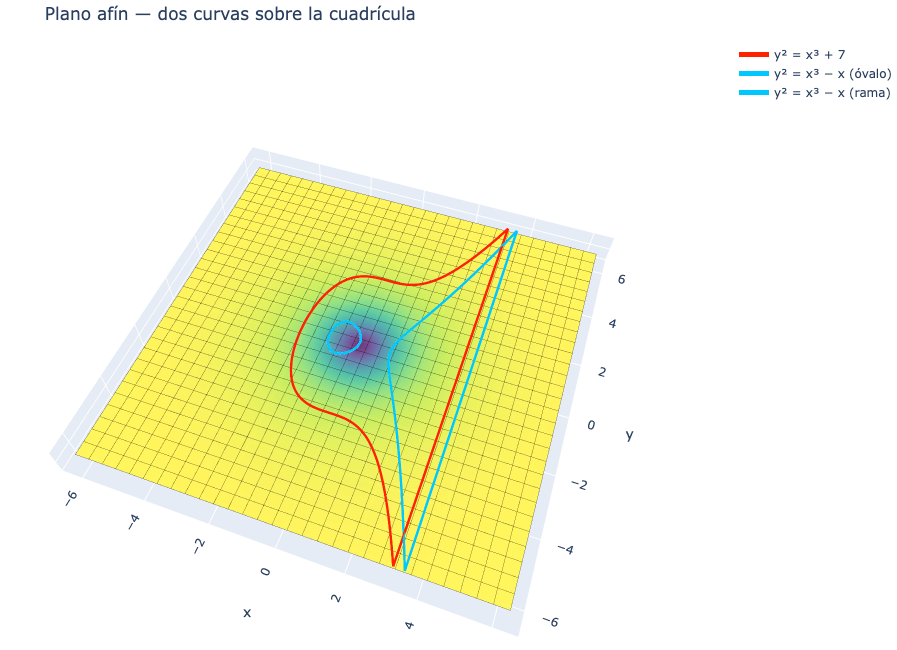

Cuadrados uniformes de la cuadrícula. El color muestra dónde cae cada cuadrado en la esfera (celda siguiente).


In [11]:
# ═══════════════════════════════════════════════════════════════════════
#  PLANO AFÍN — cuadrícula plana + y² = x³ + 7
# ═══════════════════════════════════════════════════════════════════════
fig_a = go.Figure()

# relleno coloreado (sin contornos — dibujamos las líneas reales de la cuadrícula)
fig_a.add_trace(go.Surface(
    x=Xf, y=Yf, z=np.zeros_like(Xf),
    surfacecolor=Zs_f,
    colorscale="Viridis", showscale=False, opacity=0.80,
))

# líneas de cuadrícula paramétricas
gx, gy, gz = grid_flat
fig_a.add_trace(go.Scatter3d(
    x=gx, y=gy, z=gz,
    mode="lines", line=dict(color=GRID_COLOR, width=GRID_W),
    showlegend=False, hoverinfo="skip",
))

# secp256k1:  y² = x³ + 7  (roja)
fig_a.add_trace(go.Scatter3d(
    x=flat_btc_u, y=flat_btc_v, z=np.full(len(flat_btc_u), 0.12),
    mode="lines", line=dict(color="rgb(255,34,0)", width=CURVE_W),
    name="y² = x³ + 7", showlegend=True,
))

# y² = x³ − x  óvalo (cian) — recortado al rango visible
fig_a.add_trace(go.Scatter3d(
    x=egg_u, y=egg_v, z=np.full(len(egg_u), 0.12),
    mode="lines", line=dict(color="rgb(0,200,255)", width=CURVE_W),
    name="y² = x³ − x (óvalo)", showlegend=True,
))
# y² = x³ − x  rama (cian) — recortada
mask_br_flat = (t_br <= span) & (y_br <= span)
t_brf, y_brf = t_br[mask_br_flat], y_br[mask_br_flat]
fig_a.add_trace(go.Scatter3d(
    x=np.concatenate([t_brf, t_brf[::-1]]),
    y=np.concatenate([y_brf, -y_brf[::-1]]),
    z=np.full(2*len(t_brf), 0.12),
    mode="lines", line=dict(color="rgb(0,200,255)", width=CURVE_W),
    name="y² = x³ − x (rama)", showlegend=True,
))

fig_a.update_layout(
    title="Plano afín — dos curvas sobre la cuadrícula",
    scene=dict(
        xaxis_title="x", yaxis_title="y", zaxis_title="",
        camera=dict(eye=dict(x=0.4, y=-1.1, z=1.7)),
        zaxis=dict(range=[-0.5, 0.5], showticklabels=False),
        aspectmode="manual", aspectratio=dict(x=1.2, y=1.2, z=0.10),
    ),
    height=650, width=950,
    margin=dict(l=0, r=0, t=40, b=0),
)
fig_a.show()
print("Cuadrados uniformes de la cuadrícula. El color muestra dónde cae cada cuadrado en la esfera (celda siguiente).")

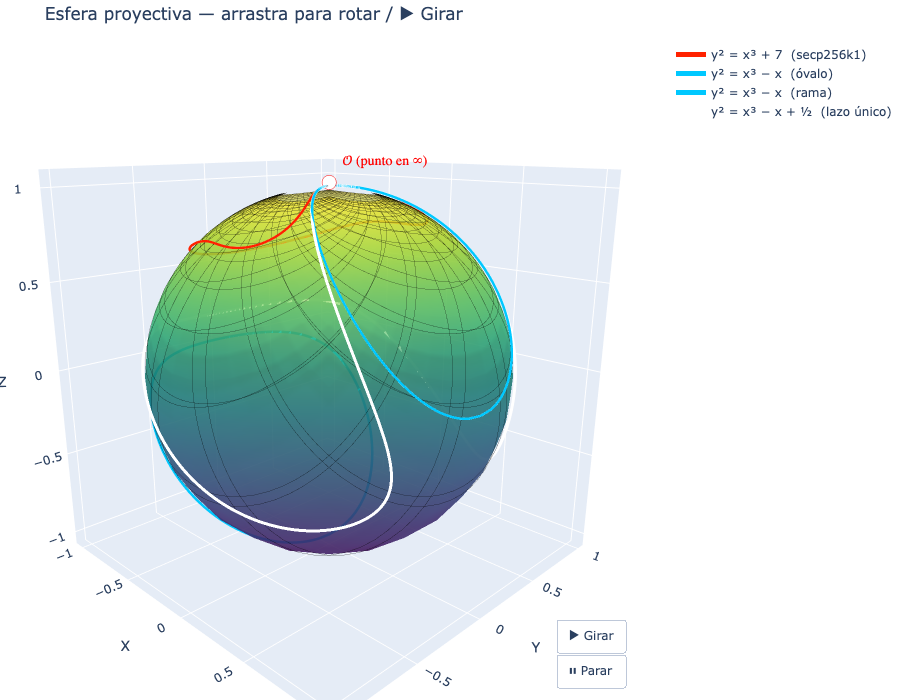

Roja  = y² = x³ + 7      (secp256k1)  — lazo pequeño abrazando el polo norte
Cian  = y² = x³ − x      (2 componentes — óvalo + rama, dos círculos separados)
Blanca = y² = x³ − x + ½  (1 componente — un solo lazo envolviendo la esfera)

Activa/desactiva cada una en la leyenda. La curva blanca es la del video de Trustica.


In [12]:
# ═══════════════════════════════════════════════════════════════════════
#  ESFERA PROYECTIVA — misma cuadrícula deformada por proyección estereográfica
#  Arrastra para rotar, o presiona ▶ Girar.
# ═══════════════════════════════════════════════════════════════════════
fig_s = go.Figure()

# relleno coloreado (sin contornos integrados)
fig_s.add_trace(go.Surface(
    x=Xs_f, y=Ys_f, z=Zs_f,
    surfacecolor=Zs_f,
    colorscale="Viridis", showscale=False, opacity=0.65,
))

# líneas de cuadrícula deformadas (cada recta del plano se convierte en curva aquí)
gx, gy, gz = grid_sphere
fig_s.add_trace(go.Scatter3d(
    x=gx, y=gy, z=gz,
    mode="lines", line=dict(color=GRID_COLOR, width=GRID_W),
    showlegend=False, hoverinfo="skip",
))

# secp256k1: y² = x³ + 7  (roja — abraza el hemisferio superior)
fig_s.add_trace(go.Scatter3d(
    x=btc_sx, y=btc_sy, z=btc_sz,
    mode="lines", line=dict(color="rgb(255,34,0)", width=CURVE_W),
    name="y² = x³ + 7  (secp256k1)", showlegend=True,
))

# y² = x³ − x  óvalo (cian — lazo por el hemisferio inferior)
fig_s.add_trace(go.Scatter3d(
    x=egg_sx, y=egg_sy, z=egg_sz,
    mode="lines", line=dict(color="rgb(0,200,255)", width=CURVE_W),
    name="y² = x³ − x  (óvalo)", showlegend=True,
))

# y² = x³ − x  rama (cian — sube hacia el polo norte)
fig_s.add_trace(go.Scatter3d(
    x=br_sx, y=br_sy, z=br_sz,
    mode="lines", line=dict(color="rgb(0,200,255)", width=CURVE_W),
    name="y² = x³ − x  (rama)", showlegend=True,
))

# y² = x³ − x + 0.5  (blanca — un solo gran lazo envolviendo toda la esfera)
fig_s.add_trace(go.Scatter3d(
    x=wrap_sx, y=wrap_sy, z=wrap_sz,
    mode="lines", line=dict(color="white", width=CURVE_W + 1),
    name="y² = x³ − x + ½  (lazo único)", showlegend=True,
))

# punto en el infinito
fig_s.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[1.03],
    mode="markers+text",
    marker=dict(size=8, color="white", line=dict(color="red", width=3)),
    text=["  𝒪 (punto en ∞)"], textposition="top right",
    textfont=dict(size=14, color="red", family="serif"),
    showlegend=False,
))

fig_s.update_layout(
    title="Esfera proyectiva — arrastra para rotar / ▶ Girar",
    scene=dict(
        xaxis_title="X", yaxis_title="Y", zaxis_title="Z",
        camera=dict(eye=dict(x=1.4, y=-1.4, z=0.6)),
        aspectmode="data",
    ),
    height=700, width=950,
    margin=dict(l=0, r=0, t=40, b=0),
)

# auto-giro
n_frames = 72
frames = []
for i in range(n_frames):
    a = 2 * np.pi * i / n_frames
    frames.append(go.Frame(
        layout=dict(scene=dict(camera=dict(
            eye=dict(x=1.8*np.cos(a), y=1.8*np.sin(a), z=0.6)))),
        name=str(i),
    ))
fig_s.frames = frames
fig_s.update_layout(updatemenus=[dict(
    type="buttons", showactive=False,
    x=0.95, y=0.02, xanchor="right", yanchor="bottom",
    buttons=[
        dict(label="▶ Girar", method="animate",
             args=[None, dict(frame=dict(duration=80, redraw=True),
                              fromcurrent=True, mode="immediate",
                              transition=dict(duration=0))]),
        dict(label="⏸ Parar", method="animate",
             args=[[None], dict(frame=dict(duration=0, redraw=False),
                                mode="immediate")]),
    ],
)])

fig_s.show()
print("Roja  = y² = x³ + 7      (secp256k1)  — lazo pequeño abrazando el polo norte")
print("Cian  = y² = x³ − x      (2 componentes — óvalo + rama, dos círculos separados)")
print("Blanca = y² = x³ − x + ½  (1 componente — un solo lazo envolviendo la esfera)")
print("\nActiva/desactiva cada una en la leyenda. La curva blanca es la del video de Trustica.")

### Punto Clave

El espacio proyectivo nos da:
1. Un **punto en el infinito** bien definido $\mathcal{O} = [0:1:0]$
2. Este punto sirve como **elemento identidad** para el grupo
3. Toda recta que pasa por dos puntos de la curva intersecta la curva en exactamente un punto más
4. No más casos especiales por "rectas paralelas" — se encuentran en el infinito

---

Generados 1000 puntos en secp256k1 mediante multiplicación escalar desde G.
G = (0x79be667ef9dcbbac…, 0x483ada7726a3c465…)


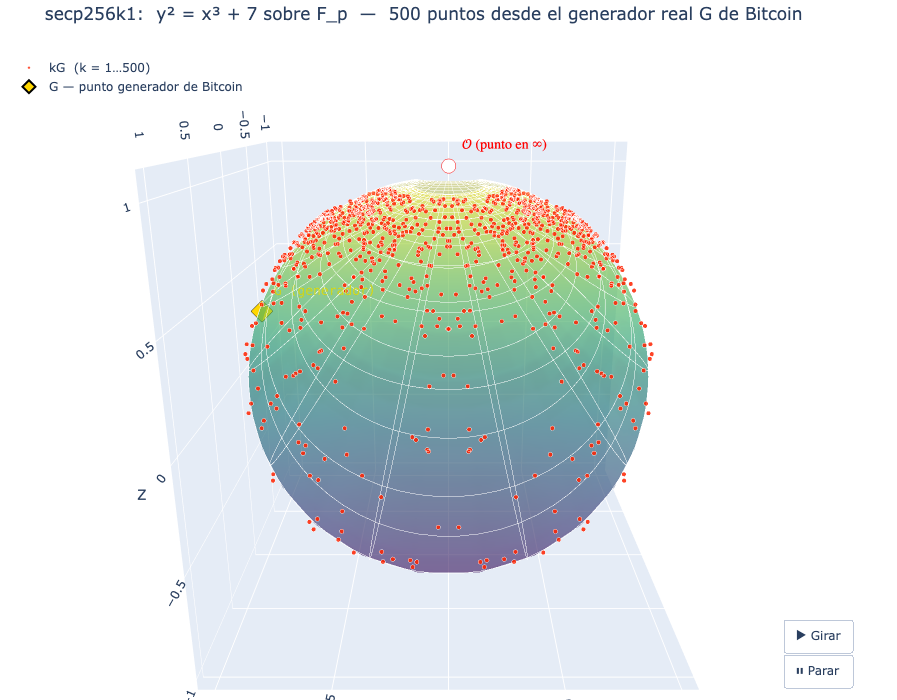


Cada punto rojo es un punto real en la curva secp256k1 de Bitcoin.
Diamante dorado = G, el punto generador codificado en cada nodo de Bitcoin.
La curva completa tiene ~2²⁵⁶ puntos — estamos viendo 500 de ellos.
Observa cómo se dispersan uniformemente — por ESO el logaritmo discreto es difícil.


In [13]:
# ═══════════════════════════════════════════════════════════════════════
#  secp256k1: y² = x³ + 7 sobre F_p  (LA curva real de Bitcoin)
#  Puntos discretos en la esfera proyectiva.
#  No podemos graficar los ~2²⁵⁶ puntos, así que muestreamos 2000 mediante
#  multiplicación escalar desde el generador real G: G, 2G, 3G, …, 2000G.
#  G se resalta en dorado.
# ═══════════════════════════════════════════════════════════════════════

# ── parámetros de secp256k1 (los mismos que usa cada nodo de Bitcoin) ───
P_SEC = 0xFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFEFFFFFC2F
N_SEC = 0xFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFEBAAEDCE6AF48A03BBFD25E8CD0364141
GX = 0x79BE667EF9DCBBAC55A06295CE870B07029BFCDB2DCE28D959F2815B16F81798
GY = 0x483ADA7726A3C4655DA4FBFC0E1108A8FD17B448A68554199C47D08FFB10D4B8

def _modinv(a, m=P_SEC):
    return pow(a, m - 2, m)

def _point_add(p1, p2):
    if p1 is None: return p2
    if p2 is None: return p1
    x1, y1 = p1; x2, y2 = p2
    if x1 == x2 and y1 != y2:
        return None
    if x1 == x2:
        lam = (3 * x1 * x1) * _modinv(2 * y1) % P_SEC
    else:
        lam = (y2 - y1) * _modinv(x2 - x1) % P_SEC
    x3 = (lam * lam - x1 - x2) % P_SEC
    y3 = (lam * (x1 - x3) - y1) % P_SEC
    return (x3, y3)

def _point_neg(p):
    if p is None: return None
    x, y = p
    return (x, (-y) % P_SEC)

NUM_POINTS = 500
G = (GX, GY)
points = []
current = None
for k in range(1, NUM_POINTS + 1):
    current = _point_add(current, G)
    points.append(current)
# Últimos NUM_POINTS del ciclo = (N-1)G, ..., (N-500)G = -G, ..., -500G (simétricos a los primeros)
points = points + [_point_neg(p) for p in points]

print(f"Generados {len(points)} puntos en secp256k1 mediante multiplicación escalar desde G.")
print(f"G = ({hex(GX)[:18]}…, {hex(GY)[:18]}…)")

# ── normalizar coordenadas de 256 bits a [-π, π] para proyección estereográfica
# Las coordenadas están esencialmente distribuidas uniformemente mod P, así que
# dividir por P y escalar a [-π, π] da una dispersión honesta.
import math
scale_sec = 2 * math.pi / P_SEC
pts_u = np.array([(x - P_SEC/2) * scale_sec for x, y in points])
pts_v = np.array([(y - P_SEC/2) * scale_sec for x, y in points])

# G específicamente
g_u = (GX - P_SEC/2) * scale_sec
g_v = (GY - P_SEC/2) * scale_sec

# Levantar sobre la esfera
fp_sx, fp_sy, fp_sz = inv_stereo(pts_u, pts_v)
R_LIFT_DOT = 1.02
fp_sx = R_LIFT_DOT * np.array(fp_sx)
fp_sy = R_LIFT_DOT * np.array(fp_sy)
fp_sz = R_LIFT_DOT * np.array(fp_sz)

g_sx, g_sy, g_sz = inv_stereo(np.array([g_u]), np.array([g_v]))
g_sx = R_LIFT_DOT * np.array(g_sx)
g_sy = R_LIFT_DOT * np.array(g_sy)
g_sz = R_LIFT_DOT * np.array(g_sz)

# ── figura ──────────────────────────────────────────────────────────────
fig_fp = go.Figure()

# superficie de la esfera translúcida
fig_fp.add_trace(go.Surface(
    x=Xs_f, y=Ys_f, z=Zs_f,
    surfacecolor=Zs_f,
    colorscale="Viridis", showscale=False, opacity=0.40,
))

# cuadrícula tenue
gx, gy, gz = grid_sphere
fig_fp.add_trace(go.Scatter3d(
    x=gx, y=gy, z=gz,
    mode="lines", line=dict(color="rgba(255,255,255,0.12)", width=1),
    showlegend=False, hoverinfo="skip",
))

# todos los puntos muestreados de la curva (rojos)
fig_fp.add_trace(go.Scatter3d(
    x=fp_sx, y=fp_sy, z=fp_sz,
    mode="markers",
    marker=dict(size=2.5, color="rgb(255,34,0)", opacity=0.85,
                line=dict(color="white", width=0.3)),
    name=f"kG  (k = 1…{NUM_POINTS})",
    text=[f"k={i+1}" if i < NUM_POINTS else f"k=-{i - NUM_POINTS + 1}" for i in range(len(points))],
    hoverinfo="text+name",
))

# punto generador G (dorado, más grande)
fig_fp.add_trace(go.Scatter3d(
    x=g_sx, y=g_sy, z=g_sz,
    mode="markers+text",
    marker=dict(size=10, color="gold",
                line=dict(color="black", width=2),
                symbol="diamond"),
    text=["  G (generador)"], textposition="top right",
    textfont=dict(size=13, color="gold", family="monospace"),
    name="G — punto generador de Bitcoin",
))

# punto en el infinito
fig_fp.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[1.05],
    mode="markers+text",
    marker=dict(size=8, color="white", line=dict(color="red", width=3)),
    text=["  𝒪 (punto en ∞)"], textposition="top right",
    textfont=dict(size=14, color="red", family="serif"),
    showlegend=False,
))

fig_fp.update_layout(
    title=f"secp256k1:  y² = x³ + 7 sobre F_p  —  {NUM_POINTS} puntos desde el generador real G de Bitcoin",
    scene=dict(
        xaxis_title="X", yaxis_title="Y", zaxis_title="Z",
        camera=dict(eye=dict(x=1.8, y=0.0, z=0.6)),
        aspectmode="data",
    ),
    height=700, width=950,
    margin=dict(l=0, r=0, t=40, b=0),
    legend=dict(x=0.01, y=0.98),
)

# auto-giro
n_frames = 72
frames = []
for i in range(n_frames):
    a = 2 * np.pi * i / n_frames
    frames.append(go.Frame(
        layout=dict(scene=dict(camera=dict(
            eye=dict(x=1.8*np.cos(a), y=0.0, z=0.6)))),
        name=str(i),
    ))
fig_fp.frames = frames
fig_fp.update_layout(updatemenus=[dict(
    type="buttons", showactive=False,
    x=0.95, y=0.02, xanchor="right", yanchor="bottom",
    buttons=[
        dict(label="▶ Girar", method="animate",
             args=[None, dict(frame=dict(duration=80, redraw=True),
                              fromcurrent=True, mode="immediate",
                              transition=dict(duration=0))]),
        dict(label="⏸ Parar", method="animate",
             args=[[None], dict(frame=dict(duration=0, redraw=False),
                                mode="immediate")]),
    ],
)])

fig_fp.show()
print(f"\nCada punto rojo es un punto real en la curva secp256k1 de Bitcoin.")
print(f"Diamante dorado = G, el punto generador codificado en cada nodo de Bitcoin.")
print(f"La curva completa tiene ~2²⁵⁶ puntos — estamos viendo {NUM_POINTS} de ellos.")
print(f"Observa cómo se dispersan uniformemente — por ESO el logaritmo discreto es difícil.")